<!-- Thêm thuộc tính để xuất ra html output không bị quá dài -->
<script>
window.addEventListener("load", function() {
  // Lấy tất cả các ô output có thể
  const outputs = document.querySelectorAll(
    '.jp-OutputArea-output, .output_area, .output_subarea'
  );

  outputs.forEach(function(output) {
    // Tính số dòng (dựa trên text)
    const text = output.innerText || "";
    const lineCount = text.split("\n").length;

    if (lineCount > 50) {
      const wrapper = document.createElement("div");
      wrapper.style.maxHeight = "300px";
      wrapper.style.overflowY = "auto";
      wrapper.style.border = "1px solid #ccc";
      wrapper.style.borderRadius = "6px";
      wrapper.style.padding = "4px";
      wrapper.style.background = "#f9f9f9";
      wrapper.title = `Collapsed: ${lineCount} lines`;

      // Di chuyển output vào wrapper
      output.parentNode.insertBefore(wrapper, output);
      wrapper.appendChild(output);
    }
  });
});
</script>

# I. Các thư viện cần thiết

In [6]:
import findspark
findspark.init()
import pyspark
findspark.find()
from pyspark.sql import SparkSession
from pyspark.sql.functions import count
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, TrainValidationSplit
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.sql.functions import udf
from pyspark.ml.linalg import VectorUDT
from pyspark.ml.regression import RandomForestRegressor
from xgboost.spark import SparkXGBRegressor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# II. Vẽ ma trận tương quan giữa các biến

=== MA TRẬN TƯƠNG QUAN CÁC ĐẶC TRƯNG ÂM NHẠC ===


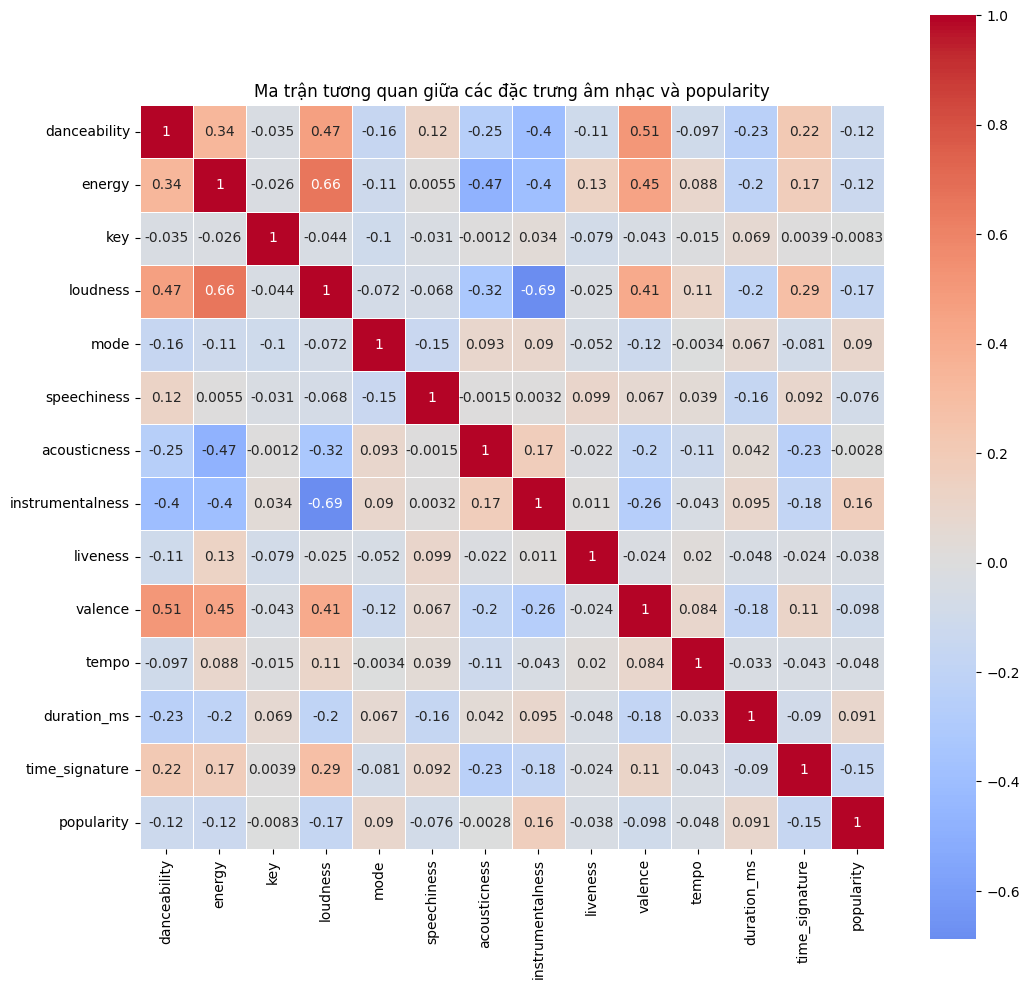

In [7]:
# Phân tích ma trận tương quan giữa các audio features
df = pd.read_csv('/opt/workspace/Final_project/data/2025_spotify_songs.csv')
print("=== MA TRẬN TƯƠNG QUAN CÁC ĐẶC TRƯNG ÂM NHẠC ===")

correlation_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms','time_signature', 'popularity']


correlation_matrix = df[correlation_features].corr()

plt.figure(figsize=(12, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng âm nhạc và popularity')
plt.show()

## Nhận xét:
- Ma trận tương quan giữa các biến input so với popularity là rất thấp.
- Nhận định hệ số quy sẽ khó có giá trị tốt, Mô hình không thể hiện được khác biệt thật chất giữa các bài hát

# III. Thực nghiệm các mô hình

## A. Khởi tạo chương trình Spark và tập dữ liệu

### Khởi tạo chương trình Spark

In [8]:
spark = (
    SparkSession.builder
    .appName("SpotifyPopularityAnalysis")
    .master("spark://spark-master:7077")
    .config("spark.driver.host", "jupyter-pyspark")
    .config("spark.driver.memory", "4g")           # Jupyter container
    .config("spark.executor.memory", "6g")         # mỗi executor 6 GB
    .config("spark.executor.cores", "4")           # giới hạn CPU
    .config("spark.sql.shuffle.partitions", "50")  # giảm size mỗi task
    .config("spark.default.parallelism", "50")
    .config("spark.sql.files.maxPartitionBytes", "64m") # chia nhỏ file
    .config("spark.rpc.message.maxSize", "512")    # max 512 MB
    .config("spark.network.timeout", "600s")
    .getOrCreate()
)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/17 06:16:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Đọc dữ liệu và làm sạch

In [9]:
spotify_data = (spark.read
                  .option("header", "true")
                  .option("inferSchema", "true")
                  .option("quote", "\"")
                  .option("escape", "\"")
                  .option("encoding", "UTF-8")
                  .option("multiLine", "true")
                  .csv("/opt/workspace/Final_project/data/2025_spotify_songs.csv"))
spotify_data.show(5)

+--------------------+------------------+--------------------+----------+--------------+---------------+-------+-------------+----------+-----------+-----------+--------------------+------------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+--------------+
|          spotify_id|              name|             artists|daily_rank|daily_movement|weekly_movement|country|snapshot_date|popularity|is_explicit|duration_ms|          album_name|album_release_date|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|time_signature|
+--------------------+------------------+--------------------+----------+--------------+---------------+-------+-------------+----------+-----------+-----------+--------------------+------------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+--------------+
|2RkZ5LkEzeHGRsmDq...|          Or

### Tạo vector input và output

In [10]:
# Chọn các input và output
features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms','time_signature']
target = 'popularity'

# Các cột đặc trưng cần convert sang double
cols_to_double = ['danceability', 'energy', 'loudness', 'mode', 'speechiness', 
                  'liveness', 'valence', 'duration_ms', 'popularity']

for c in cols_to_double:
    spotify_data = spotify_data.withColumn(c, col(c).cast("double"))

#### Kiểm tra các trường

In [11]:
print("Số dòng có giá trị null ở cột popularity:")
print (spotify_data.filter(col('popularity').isNull()).count())

Số dòng có giá trị null ở cột popularity:


0


In [12]:
spotify_data.printSchema()

root
 |-- spotify_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- daily_rank: integer (nullable = true)
 |-- daily_movement: integer (nullable = true)
 |-- weekly_movement: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- popularity: double (nullable = true)
 |-- is_explicit: boolean (nullable = true)
 |-- duration_ms: double (nullable = true)
 |-- album_name: string (nullable = true)
 |-- album_release_date: date (nullable = true)
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: double (nullable = true)
 |-- mode: double (nullable = true)
 |-- speechiness: double (nullable = true)
 |-- acousticness: double (nullable = true)
 |-- instrumentalness: double (nullable = true)
 |-- liveness: double (nullable = true)
 |-- valence: double (nullable = true)
 |-- tempo: double (nullable = 

##### Nhận xét:
- Các trường được chia đúng, không chứa null, đã được định dạng đúng kiểu dữ liệu

In [13]:
assembler = VectorAssembler(inputCols=features, outputCol="features")
data_prepared = assembler.transform(spotify_data).select("features", target)
data_prepared.show(5)

25/10/17 06:17:27 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------------+----------+
|            features|popularity|
+--------------------+----------+
|[0.368,0.694,2.0,...|      95.0|
|[0.731,0.685,7.0,...|      89.0|
|[0.436,0.723,1.0,...|      98.0|
|[0.519,0.601,6.0,...|      91.0|
|[0.747,0.507,2.0,...|     100.0|
+--------------------+----------+
only showing top 5 rows



Kiểm tra sau khi vector hoá thì có lỗi không

In [14]:
@udf("boolean")
def is_invalid(v):
    return v is None or len(v) == 0 or any([x != x or x == float("inf") or x == float("-inf") for x in v])
data_prepared.filter(is_invalid("features")).count()


0

#### Chia dữ liệu thành train (80%), test (20%)

In [8]:

train_data, test_data = data_prepared.randomSplit([0.8, 0.2], seed=16)

print("Train count:", train_data.count())
print("Test count:", test_data.count())


Train count: 443528


Test count: 111283


## B. Thử nghiệm với mô hình tuyến tính (Linear Regression)

In [11]:
# Mô hình ban đầu
lr = LinearRegression(featuresCol="features", labelCol="popularity")

# Tạo grid hyperparameter
paramGrid = (ParamGridBuilder()
    .addGrid(lr.regParam, [0.025, 0.05, 0.075, 0.1 ])
    .addGrid(lr.elasticNetParam, [0.0])
    .addGrid(lr.fitIntercept, [True, False])
    .build())

# Đánh giá bằng RMSE / R2 / MAE
evaluator = RegressionEvaluator(labelCol="popularity", metricName="rmse")

# TrainValidationSplit
tvs_lr = TrainValidationSplit(
    estimator=lr,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    trainRatio=0.75, # 75% trong train để huấn luyện, 25% để validation
    seed=16
)


# Chọn mô hình tốt nhất dựa vào validation
tvs_model = tvs_lr.fit(train_data)
best_model = tvs_model.bestModel

print("Tốt nhất regParam:", best_model._java_obj.getRegParam())
print("Tốt nhất elasticNetParam:", best_model._java_obj.getElasticNetParam())


# Đánh giá trên tập test
test_predictions = best_model.transform(test_data)
evaluator_rmse = RegressionEvaluator(labelCol="popularity", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="popularity", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="popularity", metricName="r2")

rmse = evaluator_rmse.evaluate(test_predictions)
mae = evaluator_mae.evaluate(test_predictions)
r2 = evaluator_r2.evaluate(test_predictions)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R^2: {r2}")

Tốt nhất regParam: 0.025
Tốt nhất elasticNetParam: 0.0


RMSE: 15.370693395239668
MAE: 12.17949972400671
R^2: 0.06839269968887174


#### Nhật ký thực nghiệm

<table border="1" cellspacing="0" cellpadding="5">
  <tr>
    <th rowspan="2">Mô hình</th>
    <th rowspan="2">Phương pháp đánh giá</th>
    <th rowspan="2">Chia dữ liệu</th>
    <th colspan="2">Tham số mô hình</th>
    <th colspan="2">Kết quả mô hình</th>
    <th rowspan="2">RMSE</th>
    <th rowspan="2">MAE</th>
    <th rowspan="2">R2</th>
    <th rowspan="2">Mục đích</th>
  </tr>
  <tr>
    <th>regParam</th>
    <th>elasticNetParam</th>
    <th>regParam</th>
    <th>elasticNetParam</th>
  </tr>
  <tr>
    <td rowspan="3">LinearRegression(featuresCol="features",<br>labelCol="popularity")</td>
    <td>RMSE</td>
    <td>75%</td>
    <td>[0.0, 0.001, 0.01, 0.1, 0.5]</td>
    <td>[0.0, 0.5, 1.0]</td>
    <td>0.1</td>
    <td>0</td>
    <td>15.3707</td>
    <td>12.1801</td>
    <td>0.06839</td>
    <td>Xác định miền tham số có tiềm năng</td>
  </tr>
  <tr>
    <td>MAE</td>
    <td>75%</td>
    <td>[0.05, 0.1, 0.15, 0.2]</td>
    <td>[0.0, 0.01, 0.05]</td>
    <td>0.05</td>
    <td>0</td>
    <td>15.3707</td>
    <td>12.1797</td>
    <td>0.06839</td>
    <td>Tối ưu lại vùng tham số có hiệu suất cao nhất</td>
  </tr>
  <tr>
    <td>R2</td>
    <td>75%</td>
    <td>[0.0, 0.001, 0.01, 0.1, 0.5]</td>
    <td>[0.025, 0.05, 0.0075]</td>
    <td>0.025</td>
    <td>0</td>
    <td>15.3707</td>
    <td>12.1795</td>
    <td>0.06839</td>
    <td>Tối ưu lại vùng tham số có hiệu suất cao nhất</td>
  </tr>
  <tr>
    <td colspan="11"><i>Lý do dừng huấn luyện: Mô hình không thể dự đoán được bất kỳ yếu tố nào (độ chính xác ~6.8%)</i></td>
  </tr>
</table>


#### Nhận xét:
- Mô hình hoàn toàn không dự đoán được gì
- Đúng như nhận định ban đầu về tính tương quan giữa các biến input và ouput
- Nhận định tiếp theo: thử nghiệm với các mô hình phi tuyến khác

## C. Thử nghiệm với mô hình phi tuyến

### 1. RandomForest

In [ ]:
rf = RandomForestRegressor(featuresCol="features", labelCol="popularity")
evaluator = RegressionEvaluator(labelCol="popularity", metricName="r2")
paramGrid = ParamGridBuilder() \
  .addGrid(rf.numTrees, [65,70]) \
  .addGrid(rf.maxDepth, [25,30]) \
  .addGrid(rf.maxBins, [32]) \
 .build()

# TrainValidationSplit
tvs_rf = TrainValidationSplit(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    trainRatio=0.75, # 75% trong train để huấn luyện, 25% để validation
    seed=16
)

# Chọn mô hình tốt nhất dựa vào validation
tvs_model = tvs_rf.fit(train_data)
best_rf_model = tvs_model.bestModel

25/10/16 12:31:07 WARN CacheManager: Asked to cache already cached data.
25/10/16 12:31:07 WARN CacheManager: Asked to cache already cached data.
25/10/16 12:31:10 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
25/10/16 12:31:14 WARN DAGScheduler: Broadcasting large task binary with size 43.7 MiB
25/10/16 12:31:20 WARN DAGScheduler: Broadcasting large task binary with size 5.7 MiB
25/10/16 12:31:24 WARN DAGScheduler: Broadcasting large task binary with size 54.1 MiB
25/10/16 12:31:25 WARN DAGScheduler: Broadcasting large task binary with size 1237.0 KiB
25/10/16 12:31:29 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/10/16 12:31:30 WARN DAGScheduler: Broadcasting large task binary with size 6.1 MiB
25/10/16 12:31:33 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
25/10/16 12:31:36 WARN DAGScheduler: Broadcasting large task binary with size 64.5 MiB
25/10/16 12:31:39 WARN DAGScheduler: Broadcasting large task binary with s

25/10/16 13:00:03 WARN DAGScheduler: Broadcasting large task binary with size 1081.6 KiB
25/10/16 13:00:10 WARN DAGScheduler: Broadcasting large task binary with size 144.1 MiB
25/10/16 13:00:26 WARN DAGScheduler: Broadcasting large task binary with size 144.9 MiB
25/10/16 13:00:43 WARN DAGScheduler: Broadcasting large task binary with size 145.4 MiB


In [ ]:
print("Tốt nhất numTrees:", best_rf_model._java_obj.getNumTrees())
print("Tốt nhất maxDepth:", best_rf_model._java_obj.getMaxDepth())
print("Tốt nhất maxBins:", best_rf_model._java_obj.getMaxBins())


# Đánh giá trên tập test
test_predictions = best_rf_model.transform(test_data)
evaluator_rmse = RegressionEvaluator(labelCol="popularity", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="popularity", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="popularity", metricName="r2")

rmse = evaluator_rmse.evaluate(test_predictions)
mae = evaluator_mae.evaluate(test_predictions)
r2 = evaluator_r2.evaluate(test_predictions)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R^2: {r2}")

Tốt nhất numTrees: 70
Tốt nhất maxDepth: 30
Tốt nhất maxBins: 32


RMSE: 6.981733071780427
MAE: 3.3063065533379015
R^2: 0.8077915638343556


#### Nhật ký thực nghiệm

<table>
    <tr>
        <td>Mô hình</td>
        <td>Phương pháp đánh giá</td>
        <td>Chia dữ liệu</td>
        <td>Tham số mô hình</td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td>Kết quả mô hình</td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td>Mục đích</td>
    </tr>
    <tr>
        <td></td>
        <td></td>
        <td></td>
        <td>numTrees</td>
        <td>maxDepth</td>
        <td>maxBins</td>
        <td>minInstancesPerNode</td>
        <td>featureSubsetStrategy</td>
        <td>numTrees</td>
        <td>maxDepth</td>
        <td>maxBins</td>
        <td>minInstancesPerNode</td>
        <td>featureSubsetStrategy</td>
        <td>RMSE</td>
        <td>MAE</td>
        <td>R2</td>
        <td></td>
    </tr>
    <tr>
        <td>RandomForestRegressor(featuresCol=&quot;&quot;features&quot;&quot;, labelCol=&quot;&quot;popularity&quot;&quot;)</td>
        <td>R2</td>
        <td>75%</td>
        <td>[20, 50, 100]</td>
        <td>[5, 10, 15]</td>
        <td>[32, 64]  </td>
        <td>defaul</td>
        <td>defaul</td>
        <td>100</td>
        <td>15</td>
        <td>32</td>
        <td>defaul</td>
        <td>defaul</td>
        <td>7.641734584</td>
        <td>4.074485862</td>
        <td>0.769733976</td>
        <td>Xác định miền tham số có tiềm năng</td>
    </tr>
    <tr>
        <td></td>
        <td>R2</td>
        <td>75%</td>
        <td>vs</td>
        <td>[15]</td>
        <td>[32]  </td>
        <td>[1, 2, 4]</td>
        <td>&quot;&quot;auto&quot;&quot;, &quot;&quot;sqrt&quot;&quot;, &quot;&quot;log2&quot;&quot;, &quot;&quot;onethird&quot;&quot;, &quot;&quot;all&quot;&quot; ]</td>
        <td>100</td>
        <td>15</td>
        <td>32</td>
        <td>1</td>
        <td>auto</td>
        <td>7.664134996</td>
        <td>4.097570614</td>
        <td>0.768382028</td>
        <td>Đánh giá chiến lược random feature</td>
    </tr>
    <tr>
        <td></td>
        <td>R2</td>
        <td>75%</td>
        <td>[80, 100, 150]</td>
        <td> [15]</td>
        <td>[32]  </td>
        <td>defaul</td>
        <td>defaul</td>
        <td>80</td>
        <td>15</td>
        <td>32</td>
        <td>defaul</td>
        <td>defaul</td>
        <td>7.631334096</td>
        <td>4.063960969</td>
        <td>0.770360338</td>
        <td>Từ những kết quả trên sẽ đi tìm vùng hiệu quả của các tham số. Tách nhỏ ra để hạn chế việc tràn heap trong lúc train</td>
    </tr>
    <tr>
        <td></td>
        <td>R2</td>
        <td>75%</td>
        <td>[80,85]</td>
        <td>[15,20]</td>
        <td>[32]</td>
        <td>defaul</td>
        <td>defaul</td>
        <td>80</td>
        <td>20</td>
        <td>32</td>
        <td>defaul</td>
        <td>defaul</td>
        <td>7.016267141</td>
        <td>3.35761011</td>
        <td>0.805885402</td>
        <td></td>
    </tr>
    <tr>
        <td></td>
        <td>R2</td>
        <td>75%</td>
        <td>[80]</td>
        <td>[20]</td>
        <td>[16]</td>
        <td>defaul</td>
        <td>defaul</td>
        <td>80</td>
        <td>20</td>
        <td>16</td>
        <td>defaul</td>
        <td>defaul</td>
        <td>7.02472361</td>
        <td>3.349246212</td>
        <td>0.805417201</td>
        <td></td>
    </tr>
    <tr>
        <td></td>
        <td>R2</td>
        <td>75%</td>
        <td>[75 , 80]</td>
        <td>[20, 25]</td>
        <td>[16,32]</td>
        <td>defaul</td>
        <td>defaul</td>
        <td>75</td>
        <td>25</td>
        <td>32</td>
        <td>defaul</td>
        <td>defaul</td>
        <td>6.983807106</td>
        <td>3.308717147</td>
        <td>0.80767735</td>
        <td></td>
    </tr>
    <tr>
        <td></td>
        <td>R2</td>
        <td>75%</td>
        <td>[65,70]</td>
        <td>[25,30]</td>
        <td>[32]</td>
        <td>defaul</td>
        <td>defaul</td>
        <td>70</td>
        <td>30</td>
        <td>32</td>
        <td>defaul</td>
        <td>defaul</td>
        <td>6.981733072</td>
        <td>3.306306553</td>
        <td>0.807791564</td>
        <td></td>
    </tr>
    <tr>
        <td></td>
        <td>R2</td>
        <td>75%</td>
        <td>[50,55,65]</td>
        <td>[30]</td>
        <td>[32]</td>
        <td>defaul</td>
        <td>defaul</td>
        <td>55</td>
        <td>30</td>
        <td>32</td>
        <td>defaul</td>
        <td>defaul</td>
        <td>6.983112043</td>
        <td>3.306190585</td>
        <td>0.80771563</td>
        <td>Tối ưu lại vùng tham số có hiệu suất cao nhất</td>
    </tr>
    <tr>
        <td>Lý do dừng huấn luyện: việc tiếp tục tối ưu hoá mang lại hiệu suất không đáng kể, đánh giá rằng mô hình đã bão hoà với mức suất trên chỉ số R2 là khoảng 0.8079 (khoảng 80,79%)</td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td>6.981733072</td>
        <td>3.306190585</td>
        <td>0.807791564</td>
        <td></td>
    </tr>
</table>

#### Nhận xét:
- Kết quả mô hình là rất tốt (80,78%)
- Mô hình có thể giải thích được mối liên quan giữa input và output

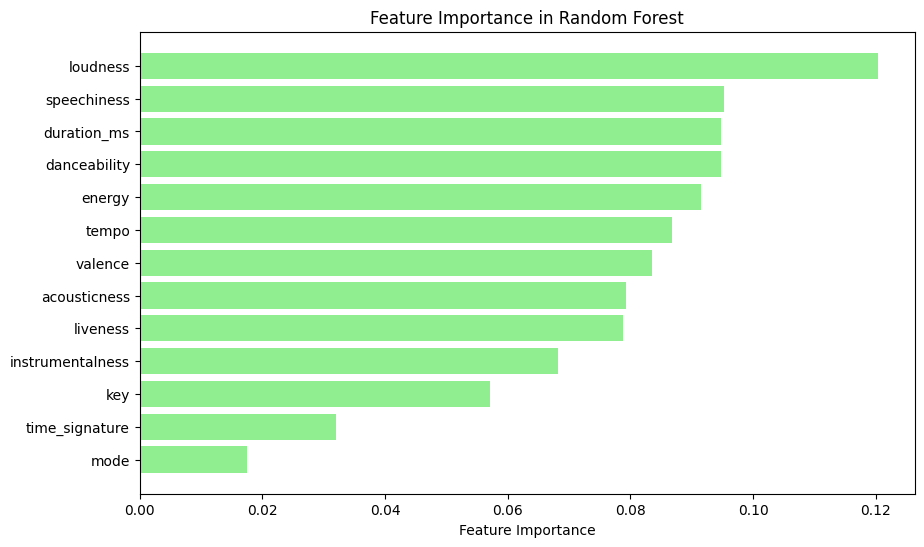

In [ ]:

importance_dict = best_rf_model.featureImportances

# Chuyển vector importances thành dictionary map tên đặc trưng - giá trị
mapped_importance = {features[i]: importance_dict[i] for i in range(len(features))}

# Chuyển thành danh sách để vẽ
features_list = list(mapped_importance.keys())
importance_list = list(mapped_importance.values())

# Sắp xếp theo giá trị giảm dần
sorted_features = sorted(mapped_importance.items(), key=lambda x: x[1], reverse=True)

# Tách thành 2 list để vẽ
features_list = [x[0] for x in sorted_features]
importance_list = [x[1] for x in sorted_features]

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.barh(features_list, importance_list, color='lightgreen')
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest')
plt.gca().invert_yaxis()
plt.show()

#### Nhận xét:
- Với mô hình có độ chính xác hơn 80% thì có thể tin tưởng vào các yếu tố mà mô hình dựa vào để dự đoán về độ phổ biến của 1 bài hát
- Có khá nhiều yếu đố ảnh hưởng đến độ phổ biến như: loudness (độ to), speechiness(tỷ lệ yếu tố lời nói), duration (thời gian), Danceability (Mức độ có thể nhảy được), energy (năng lượng)
- Ngoài ra còn có những yếu tố được xem là cá nhân, không ảnh hưởng đến độ nổi tiếng của bài hát như time_signature (nhịp bài hát), mode (điệu), key (độ cao chính)

### 2. XGBoost


In [ ]:
xgb = SparkXGBRegressor(
    features_col="features",
    label_col="popularity",
    prediction_col="prediction",
    objective="reg:squarederror",
    num_workers=4,
    seed=16
)

evaluator = RegressionEvaluator(
    labelCol="popularity",
    predictionCol="prediction",
    metricName="rmse"
)

paramGrid = (ParamGridBuilder()
    .addGrid(xgb.max_depth, [10])
    .addGrid(xgb.learning_rate, [0.15, 0.17, 0.2])
    .addGrid(xgb.n_estimators, [300, 320, 350, 370, 400])
    .addGrid(xgb.subsample, [1.0])
    .addGrid(xgb.colsample_bytree, [0.5, 0.6])
    .build())

# TrainValidationSplit
tvs_xg = TrainValidationSplit(
    estimator=xgb,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    trainRatio=0.75, # 75% trong train để huấn luyện, 25% để validation
    seed=16
)

# Chọn mô hình tốt nhất dựa vào validation
tvs_model = tvs_xg.fit(train_data)
best_xgb_model = tvs_model.bestModel


2025-10-16 10:59:10,412 INFO XGBoost-PySpark: _fit Running xgboost-3.0.5 on 4 workers with
	booster params: {'colsample_bytree': 0.5, 'device': 'cpu', 'learning_rate': 0.15, 'max_depth': 10, 'objective': 'reg:squarederror', 'subsample': 1.0, 'seed': 16, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 300}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
[10:59:15] [0]	training-rmse:15.02113                               (0 + 4) / 4]
[10:59:15] [1]	training-rmse:14.19904
[10:59:15] [2]	training-rmse:13.35767
[10:59:15] [3]	training-rmse:12.58337
[10:59:15] [4]	training-rmse:12.06150
[10:59:15] [5]	training-rmse:11.62912
[10:59:15] [6]	training-rmse:11.27772
[10:59:15] [7]	training-rmse:10.89519
[10:59:15] [8]	training-rmse:10.60956
[10:59:15] [9]	training-rmse:10.38176
[10:59:15] [10]	training-rmse:10.22510
[10:59:15] [11]	training-rmse:10.02903
[10:59:15] [12]	training-rmse:9.79701
[10:59:15] [13]	training-rmse:9.65334
[10:59:15] [14]	training-rmse:9.5

In [ ]:
# Lấy tên các tham số đã thử nghiệm trong paramGrid
param_names = set()
for param_map in paramGrid:
    for param in param_map:
        param_names.add(param.name)

# Lấy tham số hiện tại của mô hình và lọc lấy các tham số trong paramGrid
best_params = {}
for param_name in param_names:
    try:
        # Lấy Param object theo tên
        param_obj = next(p for p in best_xgb_model.params if p.name == param_name)
        value = best_xgb_model.getOrDefault(param_obj)
        best_params[param_name] = value
    except StopIteration:
        best_params[param_name] = None
    except KeyError:
        best_params[param_name] = None

print("Best tuned Params:")
print(best_params)

# Đánh giá trên tập test
test_predictions = best_xgb_model.transform(test_data)
evaluator_rmse = RegressionEvaluator(labelCol="popularity", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="popularity", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="popularity", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(test_predictions)
mae = evaluator_mae.evaluate(test_predictions)
r2 = evaluator_r2.evaluate(test_predictions)
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R^2: {r2}")

Best tuned Params:
{'colsample_bytree': 0.6, 'n_estimators': 320, 'subsample': 1.0, 'max_depth': 10, 'learning_rate': 0.2}


RMSE: 6.919099534712618
MAE: 3.2774398626078742
R^2: 0.8112247212386894


#### Nhật ký thực nghiệm

<table>
    <tr>
        <td>Mô hình</td>
        <td>Phương pháp đánh giá</td>
        <td>Chia dữ liệu</td>
        <td>Tham số mô hình</td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td>Kết quả mô hình</td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td>Mục đích</td>
    </tr>
    <tr>
        <td></td>
        <td></td>
        <td></td>
        <td>maxDepth</td>
        <td>Learning rate</td>
        <td>n_estimators</td>
        <td>subsample</td>
        <td>colsample_bytree</td>
        <td>order</td>
        <td>maxDepth</td>
        <td>Learning rate</td>
        <td>n_estimators</td>
        <td>subsample</td>
        <td>colsample_bytree</td>
        <td>Order</td>
        <td>RMSE</td>
        <td>MAE</td>
        <td>R2</td>
        <td></td>
    </tr>
    <tr>
        <td>RandomForestRegressor(featuresCol=&quot;&quot;features&quot;&quot;, labelCol=&quot;&quot;popularity&quot;&quot;)</td>
        <td>RMSE</td>
        <td>75%</td>
        <td>[4, 6, 8, 10]</td>
        <td>[0.05, 0.1, 0.2]</td>
        <td>[100, 200]</td>
        <td>[0.7, 0.8, 1.0]</td>
        <td>[0.7, 0.8, 1.0]</td>
        <td>default</td>
        <td>10</td>
        <td>0.2</td>
        <td>200</td>
        <td>1</td>
        <td>0.7</td>
        <td>default</td>
        <td>6.951206274</td>
        <td>3.30513078</td>
        <td>0.809468706</td>
        <td>Xác định miền tham số có tiềm năng</td>
    </tr>
    <tr>
        <td></td>
        <td>RMSE</td>
        <td>75%</td>
        <td>[8, 9, 10, 11]</td>
        <td>[0.1, 0.15, 0.2]</td>
        <td>[200, 250, 300]</td>
        <td>[0.8, 0.9, 1.0]</td>
        <td>[0.6, 0.7, 0.8]</td>
        <td>default</td>
        <td>10</td>
        <td>0.2</td>
        <td>300</td>
        <td>1</td>
        <td>0.6</td>
        <td>default</td>
        <td>6.920309571</td>
        <td>3.279458424</td>
        <td>0.811158688</td>
        <td>Fine-tune vùng lân cận kết quả trên</td>
    </tr>
    <tr>
        <td></td>
        <td>RMSE</td>
        <td>75%</td>
        <td>10</td>
        <td>0.2</td>
        <td>300</td>
        <td>1</td>
        <td>0.6</td>
        <td>gamma [0, 0.1, 0.3]<br>reg_alpha [0, 0.5, 1]<br>reg_lambda, [1, 3, 5])</td>
        <td>10</td>
        <td>0.2</td>
        <td>300</td>
        <td>1</td>
        <td>0.6</td>
        <td>gamma [0]<br>reg_alpha [0]<br>reg_lambda [1] (default)</td>
        <td>6.920309571</td>
        <td>3.279458424</td>
        <td>0.811158688</td>
        <td>Với thông số tối ưu nhất, thử nghiệm với các parameter khác</td>
    </tr>
    <tr>
        <td></td>
        <td>RMSE</td>
        <td>75%</td>
        <td>10</td>
        <td>[0.2, 0.25, 0.3]</td>
        <td>[300, 350, 400]</td>
        <td>1</td>
        <td>[0.5, 0.6]</td>
        <td>default</td>
        <td>10</td>
        <td>0.2</td>
        <td>350</td>
        <td>1</td>
        <td>0.6</td>
        <td>default</td>
        <td>6.918233254</td>
        <td>3.275530661</td>
        <td>0.811271988</td>
        <td>Nếu  setup các thông số như alpha,… không hiệu quả thì sẽ quay lại để tìm các vùng lân cận nhưng hướng về việc học lâu hơn</td>
    </tr>
    <tr>
        <td></td>
        <td>RMSE</td>
        <td>75%</td>
        <td>10</td>
        <td>[0.15, 0.17, 0.2]</td>
        <td>[300, 320, 350, 370, 400]</td>
        <td>1</td>
        <td>[0.5, 0.6]</td>
        <td>default</td>
        <td>10</td>
        <td>0.2</td>
        <td>320</td>
        <td>1</td>
        <td>0.6</td>
        <td>default</td>
        <td>6.919099535</td>
        <td>3.277439863</td>
        <td>0.811224721</td>
        <td>Thử nghiệm với các learning rate và n_estimators lân cận tối ưu</td>
    </tr>
    <tr>
        <td>Lý do dừng huấn luyện: việc tiếp tục tối ưu hoá mang lại hiệu suất không đáng kể, đánh giá rằng mô hình đã bão hoà với độ chính xác tốt nhất là ~81.13% (R2)</td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td></td>
        <td>6.918233254</td>
        <td>3.275530661</td>
        <td>0.811271988</td>
        <td></td>
    </tr>
</table>

#### Nhận xét:
- Kết quả mô hình trung bình tốt hơn khi so với Random Forest (khoảng 80,12%)
- Mô hình có thể giải thích tốt mối quan hệ của các thuộc tính và độ phổ biến 

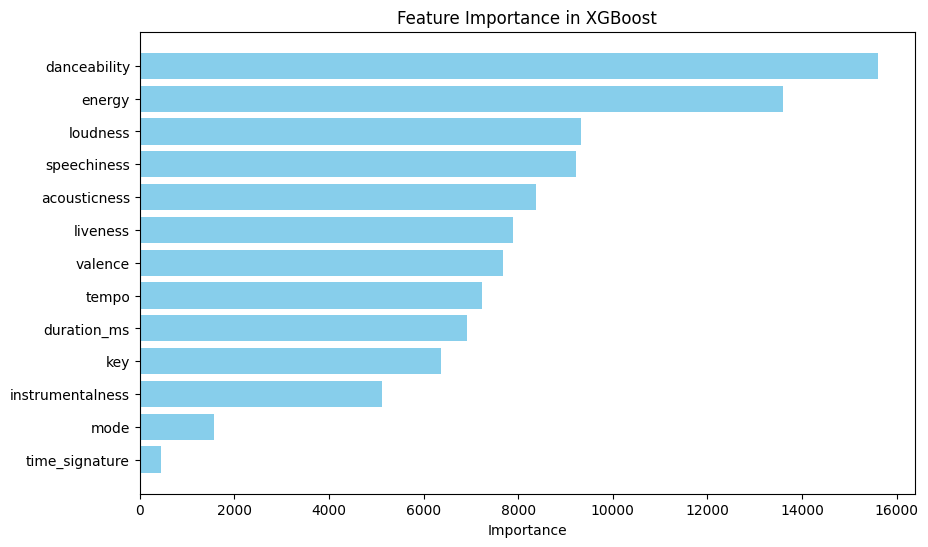

In [ ]:

booster = best_xgb_model.get_booster()
importance_dict = booster.get_score(importance_type='weight')

mapped_importance = {}
for i, (k, v) in enumerate(importance_dict.items()):
    feature_name = features[i] if i < len(features) else f'feature_{i}'
    mapped_importance[feature_name] = v

# Chuyển thành danh sách để vẽ
features_list = list(mapped_importance.keys())
importance_list = list(mapped_importance.values())

# sắp xếp tầm quan trọng của các đặc trưng
sorted_indices = np.argsort(importance_list)[::-1]
features_list = [features_list[i] for i in sorted_indices]
importance_list = [importance_list[i] for i in sorted_indices]

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.barh(features_list, importance_list, color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance in XGBoost')
plt.gca().invert_yaxis()
plt.show()


#### Nhận xét:
- Mô hình này có độ tin cậy cao nhất trong việc phân tích mối quan hệ giữa đặc trưng - độ phổ biến
- Có khá nhiều yếu đố ảnh hưởng đến độ phổ biến như: Danceability (Mức độ có thể nhảy được), energy (năng lượng), loudness (độ to), speechiness(tỷ lệ yếu tố lời nói)
- Các yếu tố được XGBoost phần tích là gần như tương tự với Random Forest, chỉ khác về tỷ trọng của các yếu tố
- Vẫn tồn tại những yếu tố cá nhân, không ảnh hưởng đến độ nổi tiếng của bài hát như time_signature (nhịp bài hát), mode (điệu).

### 3. So sánh 2 mô hình Random Forest và XGBoost


<table>
  <tr>
    <th></th>
    <th>Random Forest</th>
    <th>XGBoost</th>
  </tr>

  <tr>
    <td><b>Độ chính xác</b></td>
    <td>
      RMSE: 6.98173307178042<br>
      RMAE: 3.3063056533379<br>
      R2: 0.807791563834355
    </td>
    <td>
      RMSE: 6.9182325441787<br>
      RMAE: 3.27553066109784<br>
      R2: 0.811271988102267
    </td>
  </tr>

  <tr>
    <td><b>Sử dụng các thuộc tính để dự đoán</b></td>
    <td colspan="2">
      2 mô hình đánh giá khác nhau về sức quan trọng của các thuộc tính.
      Tuy nhiên vẫn có những thuộc tính giống nhau, cùng chiếm lượng tỷ trọng lớn trong việc đánh giá mức độ phổ biến như:
      <i>Danceability, energy, loudness, speechiness</i>.
    </td>
  </tr>

  <tr>
    <td><b>Số tham số</b></td>
    <td>
      d = 70, t = 30<br>
      node per tree = 2^d - 1<br>
      params = 70 * (2^31 - 1)<br>
      số phép tính = 2100 * n
    </td>
    <td>
      d = 350, t = 10<br>
      node per tree = 2^11 - 1<br>
      params = 350 * (2^11 - 1)<br>
      số phép tính = 3500 * n
    </td>
  </tr>

  <tr>
    <td><b>Khả năng tối ưu tính toán</b></td>
    <td>
      Ngôn ngữ thực thi: Scala / Java (JVM)<br>
      Duyệt toàn bộ giá trị feature hoặc dùng aggregation → nhiều Spark stage.<br>
      Xử lý song song: Theo các thread hoặc partition dữ liệu (không đa luồng trong executor).<br>
      Đồng bộ giữa node: Spark Shuffle (nặng IO).<br>
      Tối ưu bộ nhớ: Kém, do Java object phân tán.<br>
      Số cây và độ sâu cao → thời gian huấn luyện tăng tuyến tính.
    </td>
    <td>
      Ngôn ngữ thực thi: C++ native (qua XGBoost4J-Spark).<br>
      Cơ chế tách split: Histogram-based, nhanh hơn.<br>
      Xử lý song song: OpenMP đa luồng.<br>
      Đồng bộ node: AllReduce (Rabit/NCCL) hiệu quả hơn Spark Shuffle.<br>
      Tối ưu bộ nhớ: Dữ liệu dạng mảng liên tục (C-style array).<br>
      Có hỗ trợ GPU → nhanh hơn (boosting theo gradient).
    </td>
  </tr>

  <tr>
    <td><b>Thời gian tính toán</b><br><i>*note: lúc thực nghiệm không ghi toàn bộ*</i></td>
    <td>
      Trung bình 30–40 phút cho bộ tham số tốt với 4 mô hình.<br>
      → 1 mô hình khoảng 10–15 phút để train.
    </td>
    <td>
      Trung bình 4 phút cho một tham số tốt với top 30 mô hình.<br>
      → 1 mô hình khoảng 8–10 giây.
    </td>
  </tr>

  <tr>
    <td><b>Yêu cầu hệ thống</b></td>
    <td>
      Cần các worker có đủ RAM lớn, network tốt để shuffle cây dung lượng cao.
    </td>
    <td>
      Cần cài đặt các thư viện tính toán (numpy, pandas, xgboost, scikit-learn).<br>
      Worker yêu cầu CPU mạnh hơn, hỗ trợ GPU càng tốt.
    </td>
  </tr>

  <tr>
    <td><b>Kết luận</b></td>
    <td>
      Mô hình không yêu cầu worker cài nhiều thư viện, nhưng tính toán chậm hơn,
      chi phí cao, khó mở rộng khi số lượng cây lớn.
      → Phù hợp khi cấu hình trung bình, yêu cầu dễ triển khai.
    </td>
    <td>
      Hiệu suất cao, tận dụng tối đa đa luồng và GPU.<br>
      Tuy nhiên cài đặt phức tạp hơn và đòi hỏi hệ thống mạnh hơn.<br>
      → Là mô hình hiệu quả nhất cho bài toán này.
    </td>
  </tr>
</table>


# Tổng kết
- Việc phân tích mối quan hệ giữa các đặc trưng âm nhạc và mức độ phổ biến của bài hát là một thách thức phức tạp do mức độ tương quan giữa các biến đặc trưng với độ phổ biến là rất thấp, tối đa chỉ khoảng |0.15|. Mô hình hồi quy tuyến tính không đủ khả năng dự đoán hiệu quả do tính phi tuyến và sự phân tán không đồng đều của dữ liệu.

- Thay vào đó, các mô hình phi tuyến như Random Forest và XGBoost đã chứng minh hiệu suất vượt trội với độ chính xác dự đoán trên 80%, giúp làm rõ hơn các mối quan hệ ẩn giữa các đặc trưng và mức độ phổ biến của bài hát. XGBoost được đánh giá cao hơn về cả hiệu quả và thời gian huấn luyện, phù hợp cho các bài toán thực tế.

- Cả hai mô hình đều xác định rõ ràng những yếu tố âm nhạc quan trọng ảnh hưởng mạnh mẽ đến độ phổ biến bài hát, bao gồm danceability (khả năng nhảy), energy (năng lượng), loudness (độ to), và speechiness (tỷ lệ yếu tố lời nói). Đây là những thông tin giá trị giúp các nghệ sĩ và doanh nghiệp âm nhạc tập trung phát triển sản phẩm phù hợp, tối ưu hóa sự thành công trên thị trường.

- Như vậy, việc lựa chọn và áp dụng mô hình phi tuyến mang lại hiệu quả phân tích vượt trội, đồng thời cung cấp những gợi mở thực tiễn hữu ích cho cá nhân và tổ chức trong ngành công nghiệp âm nhạc.


# Nguồn tham thảo
1. https://xgboost.readthedocs.io/en/latest/jvm/xgboost4j_spark_tutorial.html
2. https://dmlc.github.io/2016/03/14/xgboost4j-portable-distributed-xgboost-in-spark-flink-and-dataflow.html
3. https://spark.apache.org/docs/latest/mllib-decision-tree.html
4. https://www.techscience.com/cmc/v71n2/45760/html
5. https://aicandy.vn/thuat-toan-random-forest-giai-thich-chi-tiet-va-ung-dung/
6. https://funix.edu.vn/chia-se-kien-thuc/xgboost-ung-dung-cua-xgboost/
7. https://machinelearningcoban.com/tabml_book/ch_model/random_forest.html
8. https://tuyendung.vti.com.vn/vi-VN/Blog/BlogDetail/163
9. https://vtitech.vn/xgboost-bai-12-dieu-chinh-so-luong-va-kich-thuoc-cua-decision-tree/
10. https://spark.apache.org/docs/latest/ml-tuning.html
11. https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.LinearRegression.html#pyspark.ml.regression.LinearRegression
12. Quách Đình Hoàng. 2025. Bài Lab 3 - Linear Regression. Tài liệu giảng dạy nội bộ, khoa Công Nghệ Thông tin, Đại học Sư Phạm Kỹ Thuật thành phố Hồ Chí Minh.
13. Quách Đình Hoàng. 2025. Bài Lab 4 - Classification and Regression. Tài liệu giảng dạy nội bộ, khoa Công Nghệ Thông tin, Đại học Sư Phạm Kỹ Thuật thành phố Hồ Chí Minh.